# 수출 유망국 대시보드 EDA

| # | 항목 | 확인하려는 것 |
|---|---|---|
| 1 | 준비 | 데이터 로드, 결측·단위 확인, 스케일 변환 |
| 2 | 박스플롯 | 이상치가 어디에 얼마나 있나 |
| 3 | 상관계수 히트맵 · 가설검정 | 지표끼리 어떻게 얽혀 있나, 그 관계가 통계적으로 유의한가 |
| 4 | 산점도 | 그 관계가 실제로 어떤 모양인가 |
| 5 | 다중공선성 | 중복된 지표는 무엇인가 |

---
## 1. 준비

DB 접속 정보는 코드에 적지 않고 환경변수에서 읽음

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests   # FDR 보정
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# set_theme이 rcParams를 덮어써서 폰트 설정보다 먼저 해야 함
sns.set_theme(style='whitegrid')

# 한글 폰트: 후보 중에 설치돼 있는 걸로 (Noto Sans KR이 팀 공통)
installed = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ['Noto Sans KR', 'Malgun Gothic', 'NanumGothic', 'AppleGothic']
             if f in installed), None)
if font:
    plt.rcParams['font.family'] = font
else:
    print('한글 폰트를 찾지 못함 → 그래프의 한글이 깨질 수 있음')
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 깨짐 방지

print(plt.rcParams['font.family'])

['Noto Sans KR']


In [2]:
# .env 읽어서 환경변수로 등록
# 노트북이 하위 폴더에 있어서, 위로 올라가면서 .env 있는 폴더를 루트로 잡음
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env').exists()), Path.cwd())
env_file = ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)   # 값에 '='가 들어있을 수 있어서 한 번만 나눔
            # 이미 설정돼 있는 값은 안 덮어씀
            os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

# 필수 값이 빠졌으면 접속하기 전에 에러
missing = [k for k in ['DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_NAME'] if not os.environ.get(k)]
if missing:
    raise RuntimeError(f'환경변수 없음: {", ".join(missing)} (.env 파일 확인)')

# RDS는 SSL 접속이라 인증서 필요
ssl_ca = Path(os.environ.get('DB_SSL_CA', './global-bundle.pem'))
if not ssl_ca.is_absolute():
    ssl_ca = ROOT / ssl_ca   # 상대경로면 루트 기준
if not ssl_ca.exists():
    raise FileNotFoundError(f'RDS 인증서 없음: {ssl_ca}')

# DB 연결
db_connection_url = URL.create(
    'mysql+pymysql',
    username=os.environ['DB_USER'],
    password=os.environ['DB_PASSWORD'],
    host=os.environ['DB_HOST'],
    port=int(os.environ.get('DB_PORT', 3306)),
    database=os.environ['DB_NAME'],
)
engine = create_engine(db_connection_url, connect_args={'ssl': {'ca': str(ssl_ca)}})

# integrate = 국가×연도별 통합 테이블 (군사비, GDP, 수입점유율, 분쟁위험도)
df_demand = pd.read_sql("SELECT * FROM integrate", con=engine)
print(df_demand.shape)

(4772, 9)


In [3]:
# 분석에 쓸 지표 5개
cols = ['current_usd', 'gdp_calculated', 'TIV_5Y_Share', 'human_hazard_score', 'share_gdp']

# 그래프/표에 쓸 한글 이름
LABEL = {
    'current_usd': '군사비',
    'gdp_calculated': 'GDP',
    'TIV_5Y_Share': '수입점유율',
    'human_hazard_score': '분쟁위험도',
    'share_gdp': '군사비/GDP'
}
YEAR = 2023   # 기준 연도

# 국가-연도 중복 체크
print('중복 행 수:', df_demand.duplicated(['Country', 'Year']).sum())

# 지표별 결측 개수
y = df_demand[df_demand.Year == YEAR]
print(f'\n{YEAR}년 전체: {len(y)}개국, 지표별 결측')
print(y[cols].isna().sum().rename(LABEL).to_string())

# 하나라도 비어 있으면 제외. 이후 분석은 전부 d로 함
d = y.dropna(subset=cols).copy()
print(f'\n{YEAR}년 분석 대상: {len(d)}개국 (결측 제외 {len(y) - len(d)}개국)')

# 수입점유율만 비어서 빠진 나라들. 수입이 없는 건지 데이터가 없는 건지 확인 필요
only_tiv = y[y.TIV_5Y_Share.isna() & y[[c for c in cols if c != 'TIV_5Y_Share']].notna().all(axis=1)]
print(f'수입점유율만 결측이라 빠진 국가 {len(only_tiv)}개: {", ".join(only_tiv.Country.head(15))}')

# 평균이 중앙값보다 훨씬 크면 오른쪽으로 치우친 분포
d[cols].describe().round(2)

중복 행 수: 130

2023년 전체: 194개국, 지표별 결측
군사비        40
GDP        43
수입점유율      18
분쟁위험도      27
군사비/GDP    40

2023년 분석 대상: 147개국 (결측 제외 47개국)
수입점유율만 결측이라 빠진 국가 3개: Guinea-Bissau, Kosovo, Türkiye


,current_usd,gdp_calculated,TIV_5Y_Share,human_hazard_score,share_gdp
count,147.00,147.00,147.00,147.00,147.00
mean,16017.79,702268.65,0.60,3.71,0.02
std,80426.76,2808534.65,1.40,3.15,0.03
min,11.79,2080.00,0.00,0.00,0.00
25%,285.62,19948.46,0.02,0.90,0.01
50%,1207.28,76370.39,0.08,3.10,0.02
75%,5734.85,373866.27,0.47,6.60,0.02
max,916014.70,27811517.00,10.23,9.80,0.36


### 스케일 변환

원본 `log1p`는 쓰지 않음. 값이 작은 비율 변수(군사비/GDP, 수입점유율)에서는 `log1p(x) ≈ x`라서 변환 효과가 없기 때문

- 금액·비율 4개 지표 → `log10`. 0이 섞인 지표는 최소 양수값의 절반을 더한 뒤 `log10`
- 분쟁위험도 → 0~10 점수라 변환하지 않음

In [4]:
# 로그 변환할 지표 (분쟁위험도는 0~10 점수라 그대로 둠)
LOG_COLS = ['current_usd', 'gdp_calculated', 'TIV_5Y_Share', 'share_gdp']


def log_scale(s):
    """log10 변환. 0이 있으면 최소 양수값의 절반을 더하고 변환"""
    s = s.astype(float)
    if (s > 0).all():
        return np.log10(s)
    # log10(0)은 -inf라서 작은 값을 더해줌
    # 최소 양수값의 절반이면 0인 나라가 제일 아래에 오니까 순서는 안 바뀜
    return np.log10(s + s[s > 0].min() / 2)


tf = d[cols].copy()   # 변환된 값. 뒤에서 계속 씀
tf[LOG_COLS] = tf[LOG_COLS].apply(log_scale)

# 0이 몇 개 있는지 확인
print('0 값 개수:', (d[LOG_COLS] == 0).sum().rename(LABEL).to_dict())

# log10이라 1 차이 = 10배 차이
tf.rename(columns=LABEL).describe().round(2)

0 값 개수: {'군사비': 0, 'GDP': 0, '수입점유율': 4, '군사비/GDP': 0}


,군사비,GDP,수입점유율,분쟁위험도,군사비/GDP
count,147.00,147.00,147.00,147.00,147.00
mean,3.12,4.95,-1.12,3.71,-1.82
std,0.95,0.86,1.05,3.15,0.34
min,1.07,3.32,-4.04,0.00,-3.23
25%,2.46,4.30,-1.79,0.90,-2.01
50%,3.08,4.88,-1.11,3.10,-1.82
75%,3.76,5.57,-0.33,6.60,-1.62
max,5.96,7.44,1.01,9.80,-0.44


---
## 2. 박스플롯 (이상치 탐지)

어떤 지표가 극단값에 휘둘리는지 알아야 나중에 축 스케일과 정규화 방식을 정할 수 있음

findfont: Failed to find font weight normal for Noto Sans KR, now using 100.
findfont: Failed to find font weight normal for Noto Sans KR, now using 100.
findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


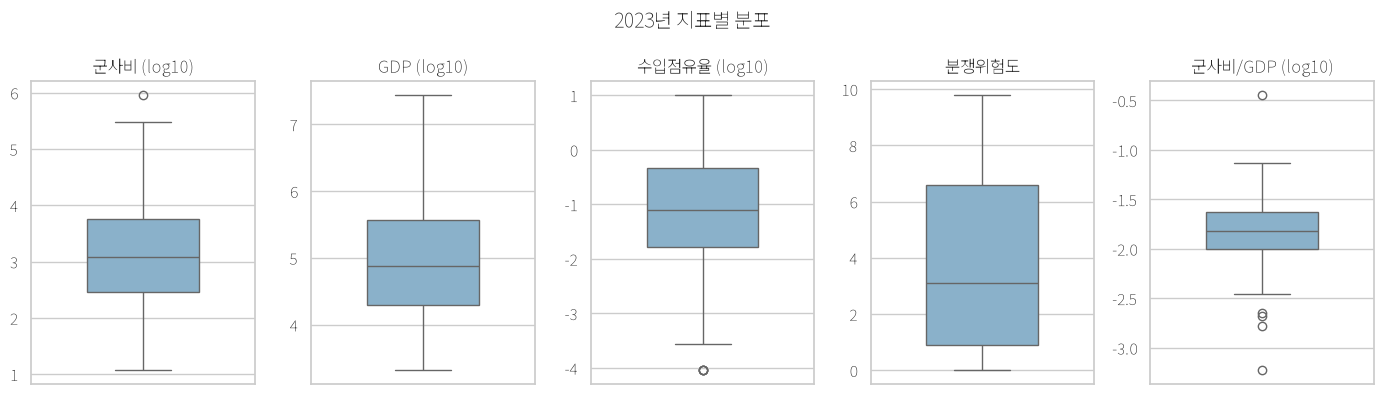

In [5]:
# 지표마다 단위가 달라서 y축은 따로
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for ax, c in zip(axes, cols):
    sns.boxplot(y=tf[c], ax=ax, color='#7FB3D5', width=0.5)
    ax.set_title(LABEL[c] + (' (log10)' if c in LOG_COLS else ''))
    ax.set_ylabel('')
plt.suptitle(f'{YEAR}년 지표별 분포')
plt.tight_layout()
plt.show()

In [6]:
# IQR 기준 이상치 개수. 원본이랑 로그 변환 후 비교
def iqr_outliers(s):
    # 박스플롯 수염이랑 같은 기준 (1.5 × IQR)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)


rows = []
for c in cols:
    raw, logged = iqr_outliers(d[c]), iqr_outliers(tf[c])
    rows.append({
        '지표': LABEL[c],
        '원본 이상치': raw.sum(),
        '로그 이상치': logged.sum(),
        '원본 기준 상위 3개국': ', '.join(d[raw].nlargest(3, c).Country),
    })
pd.DataFrame(rows).set_index('지표')

,원본 이상치,로그 이상치,원본 기준 상위 3개국
지표,,,
군사비,21,1,"United States of America, China, Russia"
GDP,18,0,"United States of America, China, Germany"
수입점유율,18,4,"India, Saudi Arabia, Ukraine"
분쟁위험도,0,0,
군사비/GDP,9,5,"Ukraine, Algeria, Saudi Arabia"


**해석**

- 원본 스케일에서 이상치가 많이 잡히는 것은 분포가 한쪽으로 치우쳐 있어서 그런 것 (진짜 이상한 값이라기보다 스케일 문제)
- 로그 스케일에서도 남는 이상치가 진짜 극단값
- 분쟁위험도는 0~10 점수라 구조적으로 극단값이 생기기 어려움

→ 군사비·GDP·수입점유율은 로그 또는 순위 변환 후 사용

---
## 3. 상관계수 히트맵

**세 가지를 같이 보는 이유**

- Pearson (원본): 직선 관계. 이상치에 약함
- Pearson (로그): 로그 변환 후의 직선 관계
- Spearman: 순위 기준. 곡선 관계나 이상치에 강함 (로그 변환해도 값이 안 변함)

원본 Pearson과 Spearman이 크게 다르면 관계는 강한데 직선이 아니라는 뜻

### 3-1. 정규성 검정

Pearson 상관계수의 유의성 검정은 두 변수가 정규분포를 따른다고 가정함 → 상관분석 전에 지표별로 정규성부터 확인

- **H0**: 해당 지표는 정규분포를 따른다
- **H1**: 정규분포를 따르지 않는다

Shapiro-Wilk 검정 사용. p-value가 유의수준(`ALPHA`)보다 작으면 H0 기각 = 정규분포가 아님

In [7]:
# 유의수준은 결과 보기 전에 미리 고정 (뒤 검정에서도 같이 씀)
ALPHA = 0.05

rows = []
for c in cols:
    # 원본은 무조건, 로그 변환한 지표는 log10도 같이 검정
    variants = [('원본', d[c])]
    if c in LOG_COLS:
        variants.append(('log10 (0 보정)' if c == 'TIV_5Y_Share' else 'log10', tf[c]))
    if c == 'TIV_5Y_Share':
        # 0인 나라는 보정해도 한 점에 몰려서, 아예 뺀 것도 따로 봄
        variants.append(('log10 (0 제외)', np.log10(d[c][d[c] > 0])))

    for tag, s in variants:
        W, p = stats.shapiro(s)
        rows.append({
            '지표': LABEL[c], '변환': tag, 'n': len(s),
            '왜도': round(stats.skew(s), 2),        # 양수면 오른쪽 꼬리가 김
            '첨도': round(stats.kurtosis(s), 2),    # 양수면 꼬리가 두꺼움
            'Shapiro W': round(W, 3),
            'p-value': f'{p:.2e}',
            '정규성': '기각' if p < ALPHA else '정규성 만족',
        })

pd.DataFrame(rows)

,지표,변환,n,왜도,첨도,Shapiro W,p-value,정규성
0,군사비,원본,147,9.94,106.18,0.173,3.38e-25,기각
1,군사비,log10,147,0.26,-0.20,0.991,4.95e-01,정규성 만족
2,GDP,원본,147,7.91,67.49,0.229,1.78e-24,기각
3,GDP,log10,147,0.34,-0.30,0.981,3.56e-02,기각
4,수입점유율,원본,147,4.18,20.86,0.463,5.45e-21,기각
5,수입점유율,log10 (0 보정),147,-0.46,0.26,0.978,1.74e-02,기각
6,수입점유율,log10 (0 제외),143,-0.12,-0.35,0.992,5.64e-01,정규성 만족
7,분쟁위험도,원본,147,0.47,-1.22,0.886,3.10e-09,기각
8,군사비/GDP,원본,147,9.13,96.76,0.342,6.45e-23,기각
9,군사비/GDP,log10,147,-0.28,3.05,0.960,2.62e-04,기각


findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


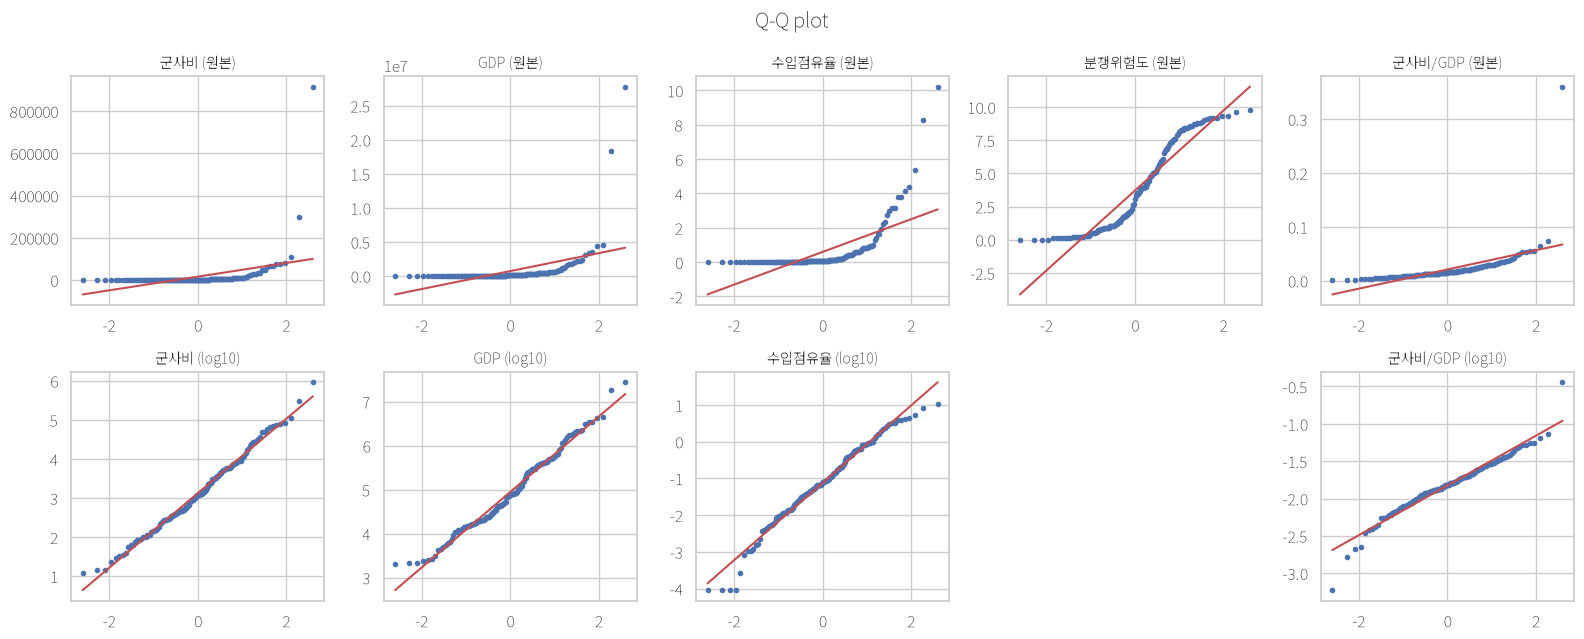

In [8]:
# Q-Q plot. 점이 직선 위에 있을수록 정규분포에 가까움
# 윗줄 원본, 아랫줄 log10 (분쟁위험도는 변환 안 해서 비워둠)
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
for j, c in enumerate(cols):
    stats.probplot(d[c], dist='norm', plot=axes[0, j])
    axes[0, j].set_title(f'{LABEL[c]} (원본)', fontsize=10)
    if c in LOG_COLS:
        stats.probplot(tf[c], dist='norm', plot=axes[1, j])
        axes[1, j].set_title(f'{LABEL[c]} (log10)', fontsize=10)
    else:
        axes[1, j].axis('off')

for ax in axes.ravel():
    ax.set_xlabel(''); ax.set_ylabel('')
    if ax.get_lines():
        ax.get_lines()[0].set_markersize(3)   # 점 크기 줄이기
plt.suptitle('Q-Q plot')
plt.tight_layout()
plt.show()

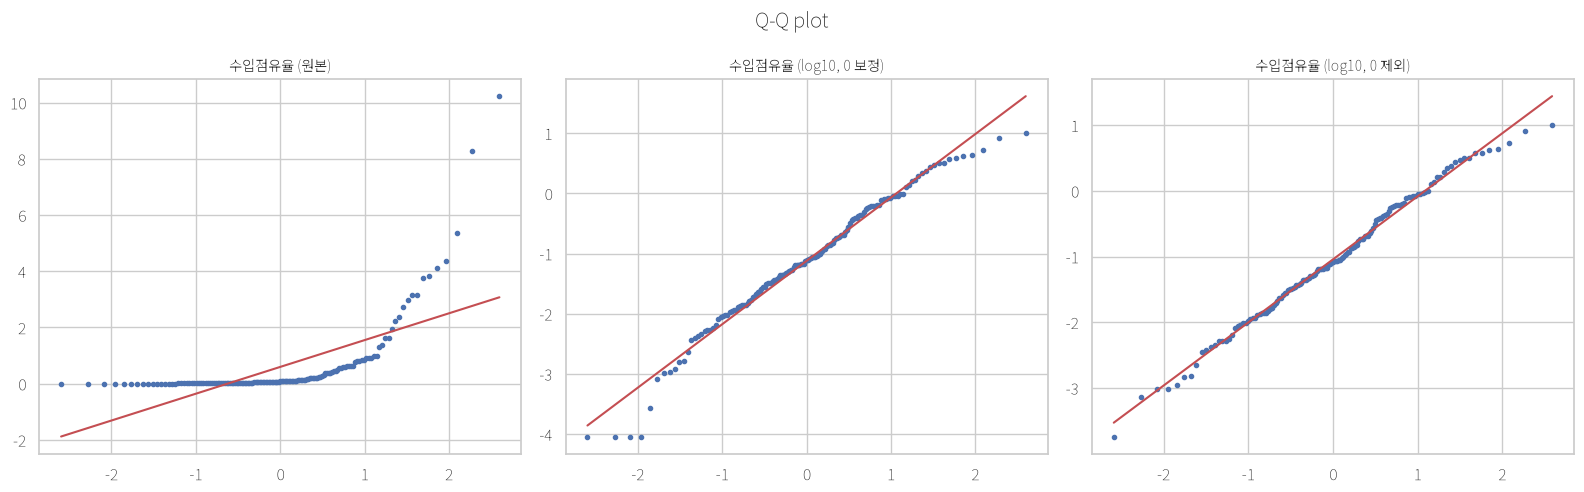

In [9]:
# 수입점유율만 따로. 0을 어떻게 처리하느냐에 따라 정규성이 달라지는지
tiv = d.TIV_5Y_Share
panels = [
    ('수입점유율 (원본)', tiv),
    ('수입점유율 (log10, 0 보정)', tf.TIV_5Y_Share),
    ('수입점유율 (log10, 0 제외)', np.log10(tiv[tiv > 0])),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, s) in zip(axes, panels):
    stats.probplot(s, dist='norm', plot=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.get_lines()[0].set_markersize(3)
plt.suptitle('Q-Q plot')
plt.tight_layout()
plt.show()

**해석**

- 원본 값에서 정규성이 기각된 지표는 원본 Pearson의 p-value를 그대로 믿을 수 없음
- 로그 변환 후 "정규성 만족"으로 바뀐 지표는 로그 값으로 Pearson을 쓸 수 있음
- 로그 변환 후에도 기각되는 지표가 있으면 → 정규성 가정이 필요 없는 **Spearman을 기본**으로 사용
- 수입점유율은 0인 국가를 보정한 경우와 제외한 경우의 결과가 다르면, 0인 국가들이 분포를 왜곡하고 있다는 뜻

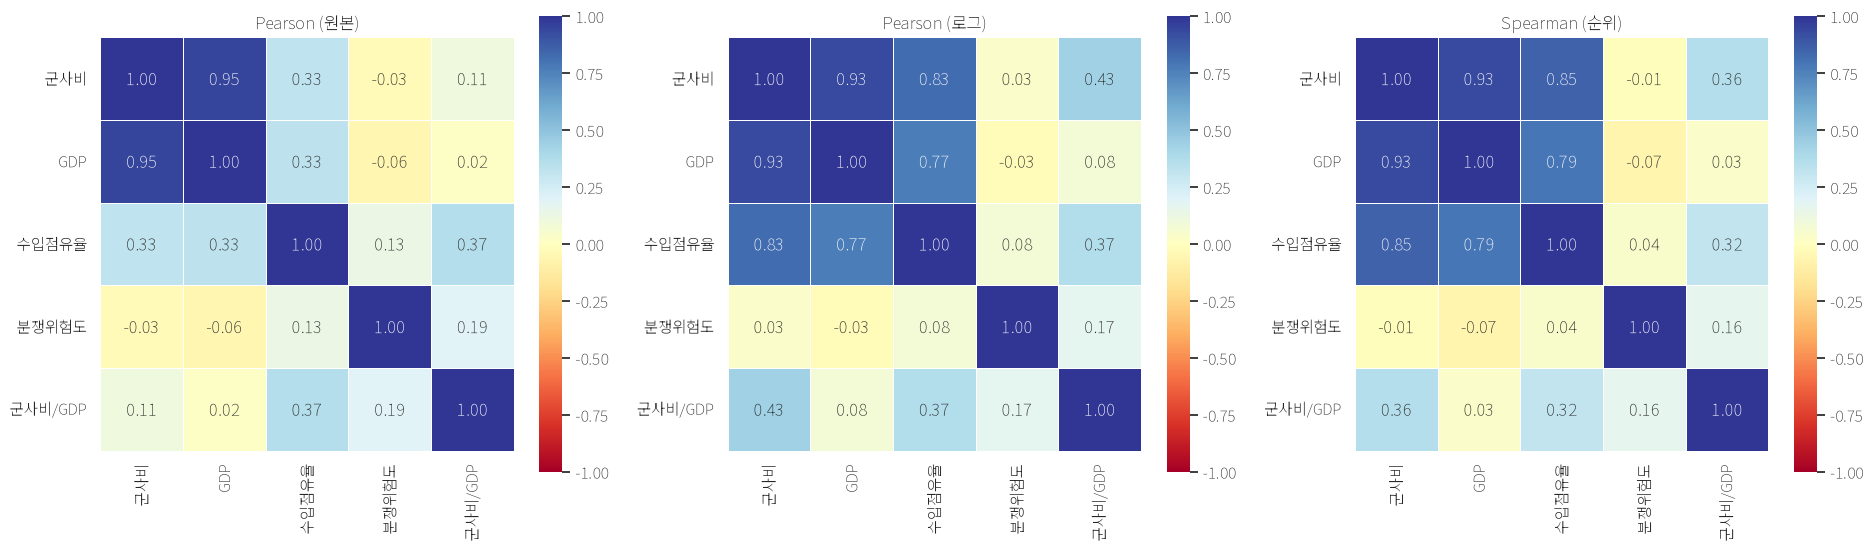

In [10]:
# 상관계수 3종류
# Spearman은 순위라 로그 변환해도 값이 같아서 원본으로만 계산
corr = {
    'Pearson (원본)': d[cols].corr('pearson'),
    'Pearson (로그)': tf[cols].corr('pearson'),
    'Spearman (순위)': d[cols].corr('spearman'),
}

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (title, m) in zip(axes, corr.items()):
    # 세 그림 색 기준을 맞추려고 vmin/vmax 고정
    sns.heatmap(m.rename(index=LABEL, columns=LABEL), annot=True, fmt='.2f', cmap='RdYlBu',
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [11]:
# 아래 해석에서 볼 쌍만 뽑아서 표로 정리
pairs = [('current_usd', 'TIV_5Y_Share'),
         ('current_usd', 'gdp_calculated'),
         ('share_gdp', 'current_usd'), ('share_gdp', 'gdp_calculated')]   # 군사비/GDP가 규모랑 따로 움직이는지
pairs += [('human_hazard_score', c) for c in cols if c != 'human_hazard_score']   # 분쟁위험도 ~ 나머지

pd.DataFrame(
    {title: [m.loc[a, b] for a, b in pairs] for title, m in corr.items()},
    index=[f'{LABEL[a]} ~ {LABEL[b]}' for a, b in pairs],
).round(2)

,Pearson (원본),Pearson (로그),Spearman (순위)
군사비 ~ 수입점유율,0.33,0.83,0.85
군사비 ~ GDP,0.95,0.93,0.93
군사비/GDP ~ 군사비,0.11,0.43,0.36
군사비/GDP ~ GDP,0.02,0.08,0.03
분쟁위험도 ~ 군사비,-0.03,0.03,-0.01
분쟁위험도 ~ GDP,-0.06,-0.03,-0.07
분쟁위험도 ~ 수입점유율,0.13,0.08,0.04
분쟁위험도 ~ 군사비/GDP,0.19,0.17,0.16


**확인할 것**

**1) 군사비 ~ 수입점유율: 원본 Pearson과 Spearman의 차이**

원본 Pearson만 보면 약한 상관으로 보여서 "군사비 큰 나라라고 무기를 많이 사는 건 아니다"라는
틀린 결론이 나올 수 있음. Spearman이 훨씬 높다면 관계는 강하고, 형태가 직선이 아니라 곡선

**2) 분쟁위험도 ~ 나머지 지표**

상관이 전부 낮다면 분쟁위험도는 다른 지표에는 없는 정보

**3) 군사비 ~ GDP**

상관이 매우 높다면 둘 다 "국가 규모"를 나타내는 사실상 같은 지표.
수입점유율도 규모와 함께 움직이는지, 군사비/GDP는 규모가 아니라 부담 수준이라 따로 움직이는지 확인

### 3-2. 상관계수 유의성 검정 + 다중비교 보정

히트맵의 상관계수만으로는 그 값이 우연히 나온 건지 알 수 없음.
표본 수(n)까지 고려해서 상관이 통계적으로 유의한지 검정

- **H0**: ρ = 0 (두 지표는 관계 없음)
- **H1**: ρ ≠ 0 (관계 있음)

**다중비교 보정이 필요한 이유**

지표 5개 → 10쌍을 한꺼번에 검정. 관계가 전혀 없어도 그중 하나가 우연히 유의하게 나올 확률이
1 − 0.95¹⁰ ≈ 40%. 그래서 Benjamini-Hochberg FDR 보정으로 기준을 조임. 보정된 p-value를 **q**로 표기

In [12]:
# 상관계수 유의성 검정 + FDR 보정
# 같은 r이어도 n에 따라 유의한지가 달라져서 n도 같이 표시함

def corr_ci(r, n, alpha=ALPHA, kind='spearman'):
    """상관계수 신뢰구간 (Fisher z 변환)

    scipy에 Spearman용 신뢰구간이 없어서 직접 만듦
    Spearman은 z의 분산이 1/(n-3)이 아니라 1.06/(n-3) (Fieller et al. 1957)
    """
    if n < 5 or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    var = 1 / (n - 3) if kind == 'pearson' else 1.06 / (n - 3)
    zc = stats.norm.ppf(1 - alpha / 2)   # 95%면 1.96
    lo, hi = np.tanh([z - zc * np.sqrt(var), z + zc * np.sqrt(var)])   # 다시 r 단위로
    return (float(lo), float(hi))


rows = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        s = d[[a, b]].dropna()
        n = len(s)
        rp, pp = stats.pearsonr(s[a], s[b])
        rs, ps = stats.spearmanr(s[a], s[b])
        rows.append({
            'x': LABEL[a], 'y': LABEL[b], 'n': n,
            'Pearson r': round(rp, 3), '_pp': pp,
            'Spearman r': round(rs, 3), '_ps': ps,
            'Spearman 95%CI': '[{:.2f}, {:.2f}]'.format(*corr_ci(rs, n)),
            # 0.2 넘으면 단조 관계는 강한데 직선은 아니라는 뜻
            '괴리(|rs|-|rp|)': round(abs(rs) - abs(rp), 3),
        })

t = pd.DataFrame(rows)

# 10쌍 p-value를 한꺼번에 FDR 보정 (q = 보정된 p)
_, q_p, _, _ = multipletests(t['_pp'], alpha=ALPHA, method='fdr_bh')
rej_s, q_s, _, _ = multipletests(t['_ps'], alpha=ALPHA, method='fdr_bh')
t['Pearson q'] = [f'{v:.2e}' for v in q_p]
t['Spearman p'] = t['_ps'].map(lambda v: f'{v:.2e}')
t['Spearman q'] = [f'{v:.2e}' for v in q_s]
t['유의(FDR)'] = np.where(rej_s, 'O', '')

# _pp, _ps는 계산용이라 빼고 출력
t.drop(columns=['_pp', '_ps'])

,x,y,n,Pearson r,Spearman r,Spearman 95%CI,괴리(|rs|-|rp|),Pearson q,Spearman p,Spearman q,유의(FDR)
0,군사비,GDP,147,0.951,0.933,"[0.91, 0.95]",-0.018,6.72e-75,3.39e-66,3.39e-65,O
1,군사비,수입점유율,147,0.325,0.854,"[0.80, 0.89]",0.528,1.45e-04,6.08e-43,3.04e-42,O
2,군사비,분쟁위험도,147,-0.032,-0.008,"[-0.17, 0.16]",-0.024,7.74e-01,9.22e-01,9.22e-01,
3,군사비,군사비/GDP,147,0.108,0.359,"[0.21, 0.50]",0.252,2.77e-01,7.77e-06,1.94e-05,O
4,GDP,수입점유율,147,0.334,0.791,"[0.72, 0.85]",0.458,1.20e-04,8.47e-33,2.82e-32,O
5,GDP,분쟁위험도,147,-0.056,-0.067,"[-0.23, 0.10]",0.011,6.27e-01,4.23e-01,6.05e-01,
6,GDP,군사비/GDP,147,0.016,0.035,"[-0.13, 0.20]",0.019,8.48e-01,6.77e-01,7.52e-01,
7,수입점유율,분쟁위험도,147,0.130,0.044,"[-0.12, 0.21]",-0.086,1.93e-01,5.99e-01,7.48e-01,
8,수입점유율,군사비/GDP,147,0.367,0.317,"[0.16, 0.46]",-0.050,2.42e-05,9.31e-05,1.86e-04,O
9,분쟁위험도,군사비/GDP,147,0.188,0.158,"[-0.01, 0.32]",-0.030,4.49e-02,5.62e-02,9.36e-02,


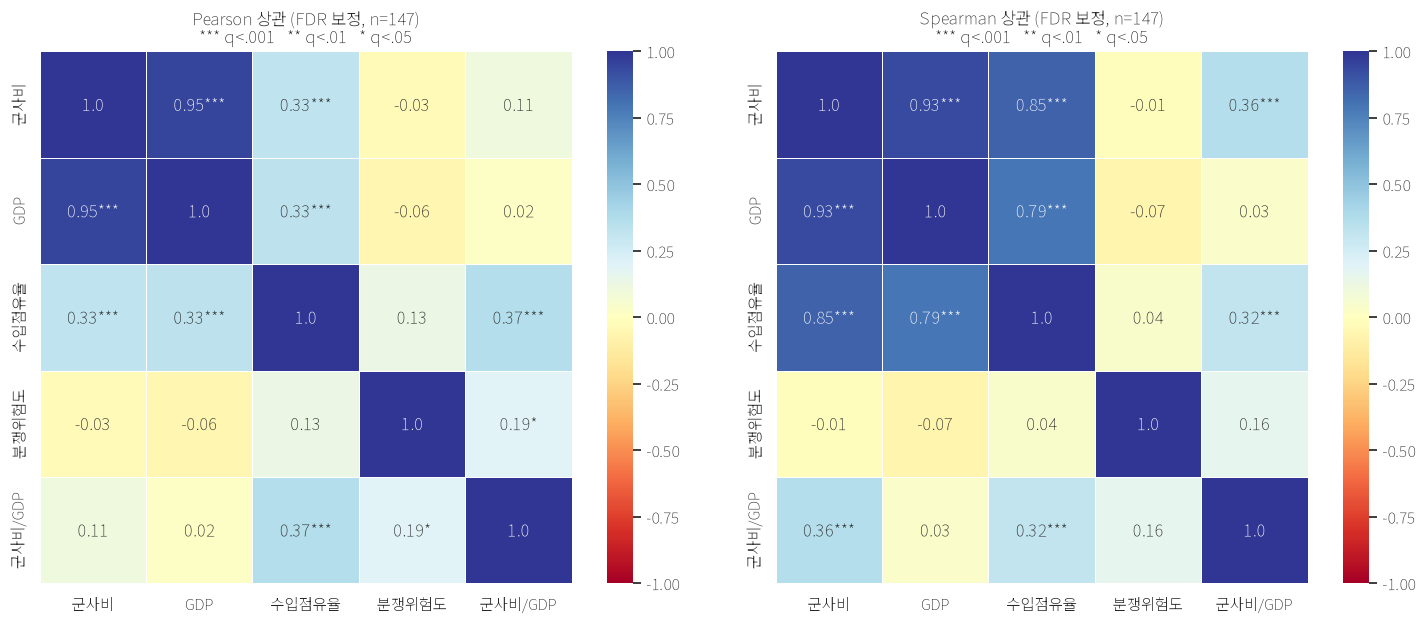

In [13]:
# 유의한 쌍에 별표 붙인 히트맵
def star(q):
    return '***' if q < .001 else '**' if q < .01 else '*' if q < .05 else ''


def annotated_heatmap(df, cols, method='spearman', ax=None):
    R = df[cols].corr(method)
    P = pd.DataFrame(np.ones_like(R), index=cols, columns=cols)   # q값 넣을 행렬

    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            s = df[[cols[i], cols[j]]].dropna()
            fn = stats.pearsonr if method == 'pearson' else stats.spearmanr
            pairs.append((i, j, fn(s[cols[i]], s[cols[j]])[1]))

    # 별표도 FDR 보정한 q 기준으로 찍음
    _, q, _, _ = multipletests([p for *_, p in pairs], method='fdr_bh')
    for (i, j, _), qq in zip(pairs, q):
        P.iloc[i, j] = P.iloc[j, i] = qq

    # 상관계수 + 별표
    ann = R.round(2).astype(str) + P.apply(lambda col: col.map(star))
    np.fill_diagonal(ann.values, '1.00')

    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 6))
    sns.heatmap(R, annot=ann, fmt='', cmap='RdYlBu', vmin=-1, vmax=1,
                square=True, linewidths=.5, ax=ax,
                xticklabels=[LABEL[c] for c in cols],
                yticklabels=[LABEL[c] for c in cols])
    ax.set_title(f'{method.capitalize()} 상관 (FDR 보정, n={len(df)})\n'
                 f'*** q<.001   ** q<.01   * q<.05')
    return ax


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
annotated_heatmap(d, cols, 'pearson', axes[0])
annotated_heatmap(d, cols, 'spearman', axes[1])
plt.tight_layout()
plt.show()

**해석**

- **Spearman q**가 `ALPHA`(0.05) 미만인 쌍만 "관계가 있다"고 서술할 수 있음
- **95% CI**가 0을 포함하면 계수가 커 보여도 방향(양/음)조차 확정할 수 없음
- **괴리**가 0.2를 넘으면 곡선 관계 의심 → 4절 산점도와 로그-로그 기울기로 형태 확인
- Pearson 열은 원본 값 기준. 3-1에서 원본의 정규성이 기각됐다면 Pearson의 유의성은 참고용으로만 볼 것

---
## 4. 산점도

상관계수는 숫자 하나라서 같은 값이어도 고르게 퍼진 경우, 두 덩어리로 나뉜 경우, 이상치 때문에 생긴 경우가 다 다름

그래서 산점도로 직접 확인

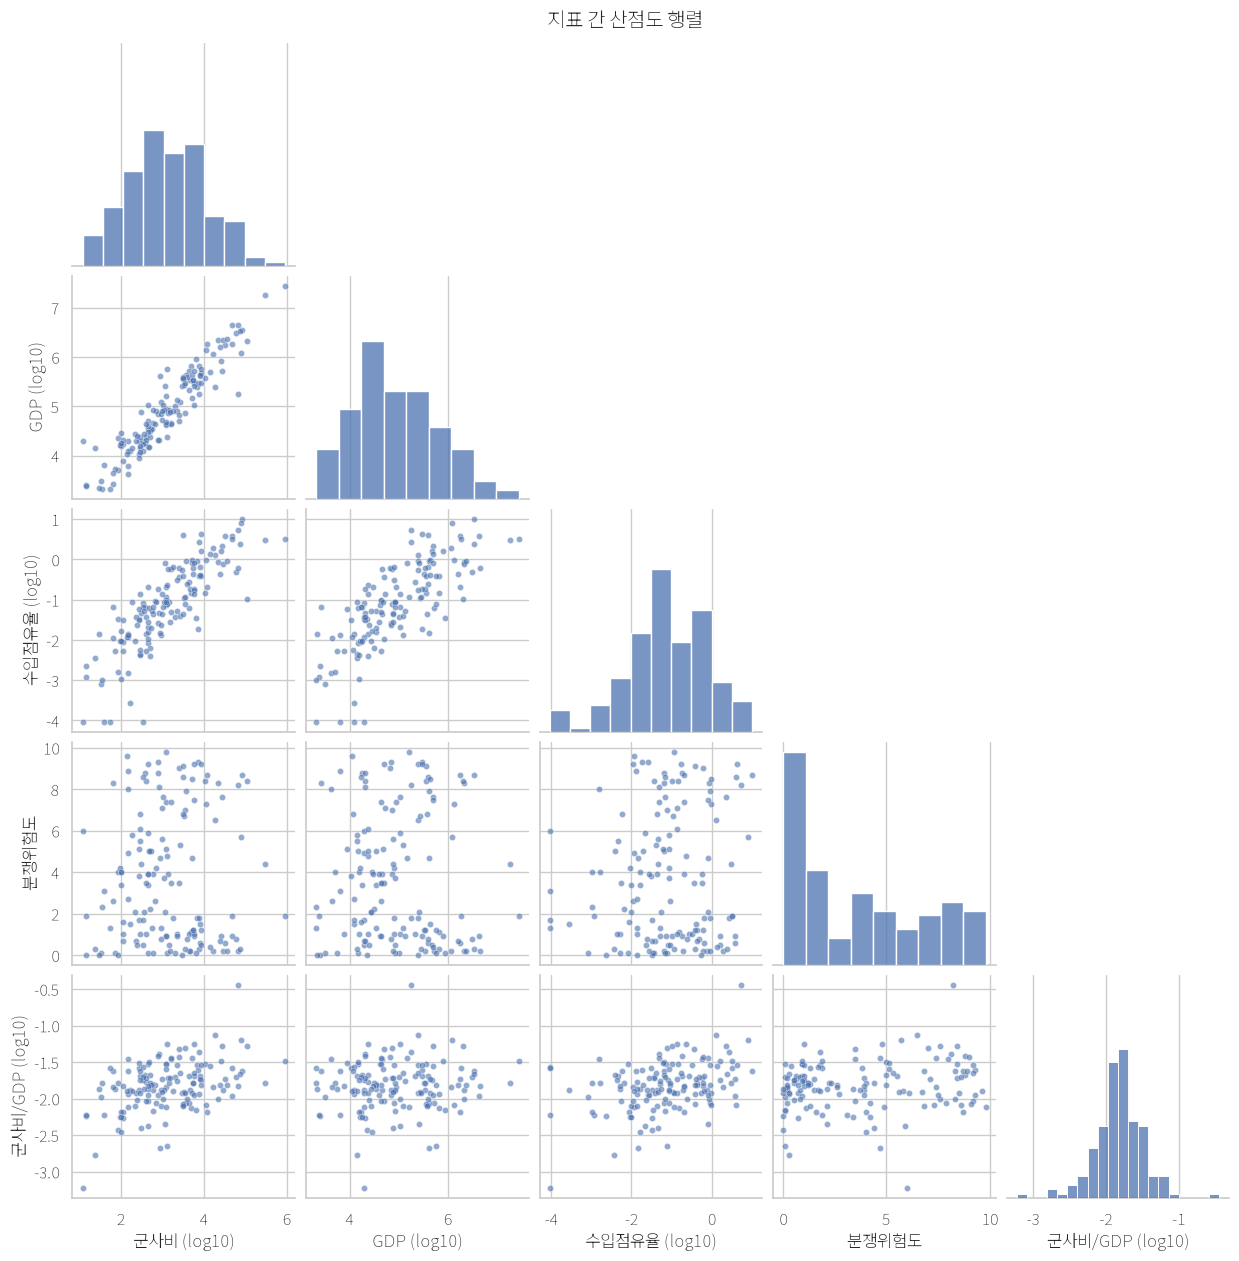

In [14]:
# 전체 쌍 산점도 (분쟁위험도 빼고 log10)
axis_label = {c: LABEL[c] + (' (log10)' if c in LOG_COLS else '') for c in cols}
# corner=True로 아래쪽 삼각형만 그림
sns.pairplot(tf.rename(columns=axis_label), corner=True, plot_kws={'s': 20, 'alpha': 0.6})
plt.suptitle('지표 간 산점도 행렬', y=1.01)
plt.show()

---
## 5. 다중공선성 (VIF)

여러 지표를 합쳐 하나의 값으로 예측할 때 변수가 겹쳐서 기울기에 혼란을 주는 경우를 막기 위함

해당 변수가 다른 변수들에 의해 얼마나 설명되는지를 뜻함

기준은 5 이상 주의, 10 이상 심각

In [18]:
# 다 넣은 경우 vs 군사비·GDP·군사비/GDP 중 하나씩 뺀 경우
candidates = {
    '5개 전부': cols,
    'GDP 제외': ['current_usd', 'share_gdp', 'TIV_5Y_Share', 'human_hazard_score'],
    '군사비 제외': ['gdp_calculated', 'share_gdp', 'TIV_5Y_Share', 'human_hazard_score'],
    '군사비/GDP 제외': ['current_usd', 'gdp_calculated', 'TIV_5Y_Share', 'human_hazard_score'],
}

# 조합별 VIF (로그 변환 값 기준)
vif_table = {}
for name, c in candidates.items():
    X = add_constant(tf[c])   # 상수항을 직접 붙여줘야 함
    # 0번 열은 상수항이라 1번부터
    vif_table[name] = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=c)

pd.DataFrame(vif_table).reindex(cols).rename(index=LABEL).round(2)

,5개 전부,GDP 제외,군사비 제외,군사비/GDP 제외
군사비,2368.89,3.39,NaN,10.46
GDP,1924.30,NaN,2.76,8.12
수입점유율,3.25,3.20,3.17,3.20
분쟁위험도,1.04,1.04,1.04,1.04
군사비/GDP,300.03,1.27,1.33,NaN


**해석**

- 5개 전부: 군사비·GDP·군사비/GDP는 한 묶음으로 중복이라 VIF가 매우 크게 나옴
- 하나를 뺀 조합: 남은 지표의 VIF가 전부 5 미만이면 쓸 수 있는 조합
- 군사비와 GDP만 남긴 조합은 둘의 상관이 높아 여전히 VIF가 클 수 있음